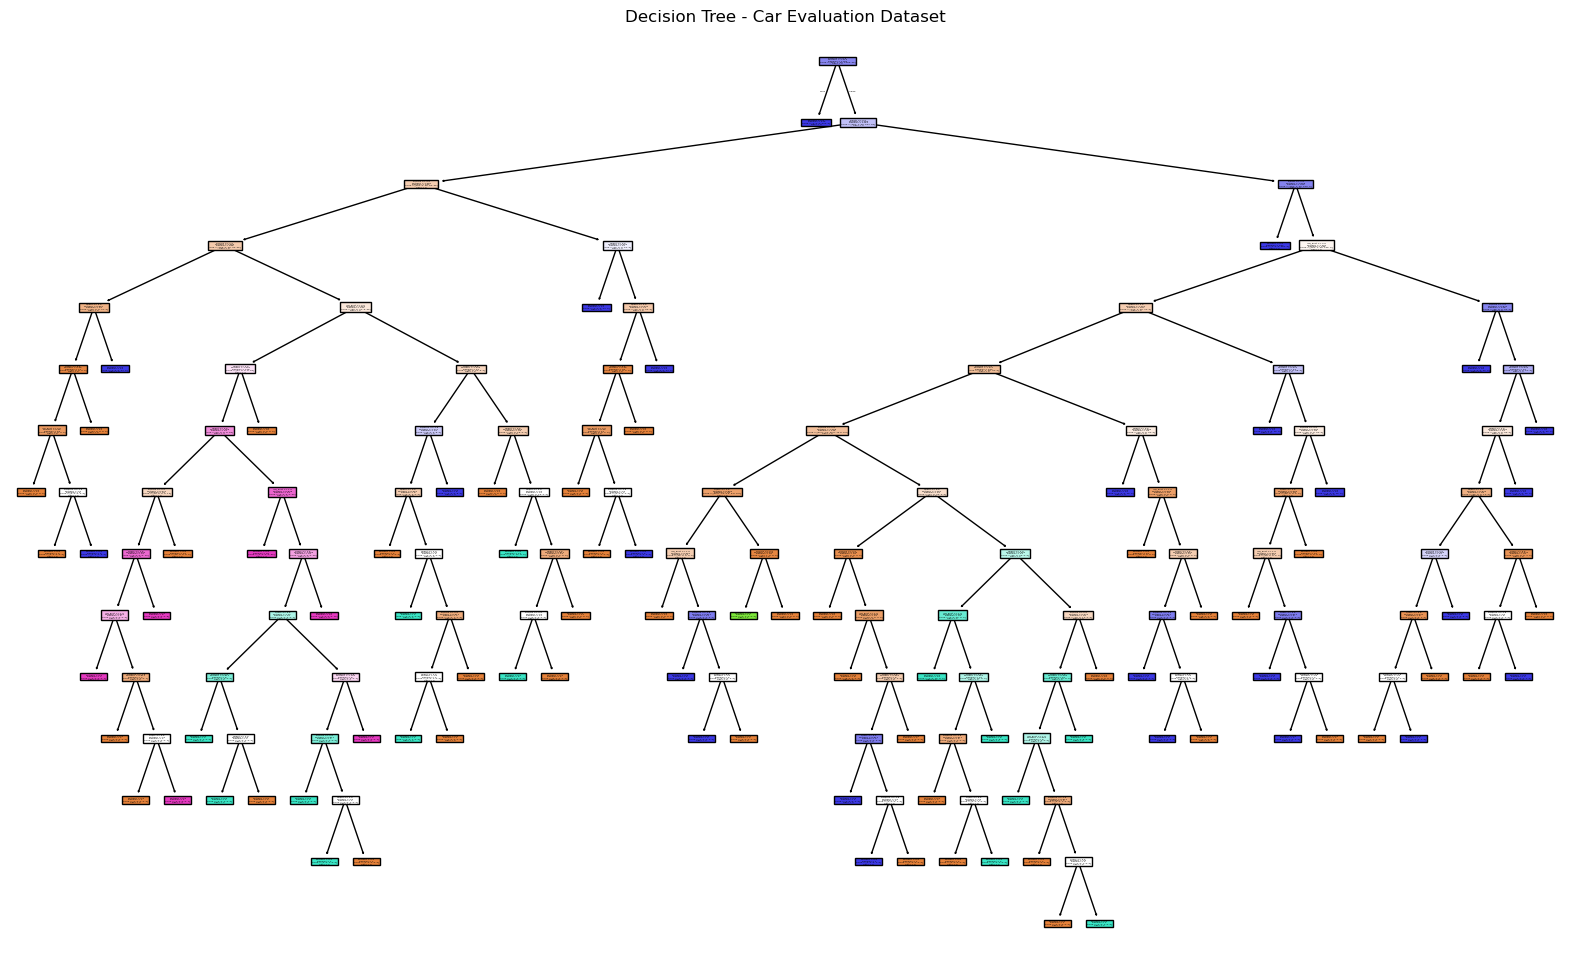

In [12]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Load Dataset Properly
# -----------------------------
df = pd.read_csv("datasets/car_evaluation.csv", header=None)

df.columns = ['buying','maint','doors','persons','lug_boot','safety','class']

# -----------------------------
# 2️⃣ Encode Categorical Data
# -----------------------------
'''
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])
'''

encoders = {}

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# -----------------------------
# 3️⃣ Separate Features & Target
# -----------------------------
X = df.drop("class", axis=1)
y = df["class"]

# -----------------------------
# 4️⃣ Train Decision Tree
# -----------------------------
dt = DecisionTreeClassifier(criterion='entropy', random_state=0)
dt.fit(X, y)

# -----------------------------
# 5️⃣ Visualize Tree
# -----------------------------
plt.figure(figsize=(20,12))

plot_tree(dt,
          feature_names=X.columns,
          class_names=dt.classes_.astype(str),
          filled=True)

plt.title("Decision Tree - Car Evaluation Dataset")
plt.show()


In [13]:
print("\nEnter Car Details:")

buying = input("Buying price (vhigh/high/med/low): ").strip()
maint = input("Maintenance cost (vhigh/high/med/low): ").strip()
doors = input("Number of doors (2/3/4/5more): ").strip()
persons = input("Capacity (2/4/more): ").strip()
lug_boot = input("Luggage boot size (small/med/big): ").strip()
safety = input("Safety (low/med/high): ").strip()

user_data = pd.DataFrame([[buying, maint, doors, persons, lug_boot, safety]],
                         columns=['buying','maint','doors','persons','lug_boot','safety'])

# Encode using stored encoders
for col in user_data.columns:
    user_data[col] = encoders[col].transform(user_data[col])

# Predict
prediction = dt.predict(user_data)

# Decode result
final_prediction = encoders['class'].inverse_transform(prediction)

print("\nPredicted Car Evaluation:", final_prediction[0])



Enter Car Details:


Buying price (vhigh/high/med/low):  vhigh
Maintenance cost (vhigh/high/med/low):  med
Number of doors (2/3/4/5more):  3
Capacity (2/4/more):  4
Luggage boot size (small/med/big):  med
Safety (low/med/high):  low



Predicted Car Evaluation: unacc
